# 📊 Exploratory Data Analysis (EDA) — Fantasy Premier League 2024/2025

## 1. Introdução

Este notebook apresenta uma Análise Exploratória de Dados (EDA) realizada sobre um conjunto de dados proveniente do repositório público *Fantasy Premier League (FPL)*, disponível em:
https://github.com/vaastav/Fantasy-Premier-League

O objetivo central da análise é preparar um dataset limpo, estruturado e apropriado para a aplicação de algoritmos de **mineração de regras de associação**, recorrendo à informação de desempenho dos jogadores ao longo das jornadas da época 2024/2025. Toda a investigação é conduzida com foco na identificação de padrões entre eventos de jogo, métricas de performance e resultados estatísticos dos jogadores.

### 1.1. O que é o Fantasy Premier League?

O *Fantasy Premier League* (FPL) é um jogo global onde milhões de utilizadores constroem equipas virtuais constituídas por jogadores reais da **Premier League inglesa**.  
Em cada jornada, os jogadores acumulam pontos com base no seu desempenho real: golos, assistências, clean sheets, minutos jogados, bónus, entre outros critérios.

O repositório utilizado nesta análise contém extrações completas da API do FPL, reunindo milhares de registos sobre estatísticas detalhadas de cada jogador em cada jornada, variando entre métricas tradicionais (golos, assistências) e métricas derivadas (influence, threat, creativity).


### 1.2. Seleção do dataset `merged_gw.csv`

Apesar de o repositório conter dezenas de ficheiros com diferentes tipos de dados (preços, estatísticas históricas, equipas, metadata de jogadores, etc.), apenas um ficheiro foi selecionado:

**`data/2024-25/gws/merged_gw.csv`**

Este dataset agrega, numa única estrutura, **todos os eventos registados em cada jornada**, para cada jogador, incluindo:

- pontos,
- minutos jogados,
- ações ofensivas e defensivas,
- contribuições esperadas (xG, xA),
- métricas avançadas,
- preço e variações,
- dados de posse e seleção,
- ações relevantes para a performance individual.

Este conjunto de dados é ideal para regras de associação, uma vez que cada linha representa uma "transação" de performance do jogador numa jornada, permitindo identificar padrões entre diferentes características.


### 1.3. Objetivo do notebook

O objetivo deste notebook consiste em:

1. Descrever e compreender o dataset selecionado.  
2. Realizar uma EDA aprofundada, abrangendo:
   - estrutura dos dados,  
   - análise estatística,  
   - identificação de problemas,  
   - tratamento e limpeza,  
   - estudo de distribuições e correlações.
3. Transformar variáveis contínuas em atributos binários adequados ao algoritmo Apriori.
4. Construir um dataset final preparado para extração de regras de associação.

Ao final da EDA, o dataset estará limpo, consistente e devidamente transformado, constituindo a base para a fase de mineração de padrões.

---

## 2. Carregamento do Dataset

Para iniciar a EDA, procede-se ao carregamento das principais bibliotecas necessárias para manipulação e visualização dos dados, seguido da leitura do ficheiro `merged_gw.csv`, localizado na estrutura de pastas do repositório.

Este ficheiro localmente encontra-se na pasta `data\merger_gw.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# use a more tolerant CSV parser to skip malformed lines that cause the ParserError
df = pd.read_csv("data/merged_gw.csv", engine='python', sep=',', on_bad_lines='skip')

df.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,modified,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,0.01,0.01,0.0,1.02,6,1,0,3.6,22.8,2024-08-17T14:00:00Z,62,False,16,0,0,0,0,1,0,4339,1,1,1,0.0,2,0,0,0,50,False,0,1
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,0.00,0.00,0.0,0.00,6,0,0,0.0,0.0,2024-08-17T14:00:00Z,0,False,3,0,0,0,0,1,0,33324,0,1,1,0.0,0,0,0,0,45,True,0,1
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,0.00,0.00,0.0,0.00,2,0,0,0.0,0.0,2024-08-17T14:00:00Z,0,False,20,0,0,0,0,1,0,8462,0,0,2,0.0,0,0,0,0,50,True,0,1
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,0,0,0,0,0.0,197,0.00,0.00,0.0,0.00,8,0,0,0.0,0.0,2024-08-18T13:00:00Z,0,False,4,0,0,0,0,1,0,716,0,1,2,0.0,0,0,0,0,45,False,0,1
4,Ben Brereton Díaz,MID,Southampton,1.0,0,0,-2,0,14.0,584,0.02,0.32,0.3,0.25,5,1,0,3.3,2.6,2024-08-17T14:00:00Z,70,False,15,0,0,0,0,1,0,66244,1,0,1,16.0,1,0,0,0,55,False,1,1


---

## 3. Estrutura do Dataset

Antes de iniciar a análise exploratória detalhada, é importante compreender a estrutura do dataset, nomeadamente o tipo de cada coluna, a presença de valores nulos e o volume total de entradas. Esta visão inicial permite identificar desde cedo:

- Que variáveis são numéricas ou categóricas

- A dimensão do dataset e o impacto que isso terá no processamento

- Possíveis colunas que necessitam de conversão de tipo ou pré-processamento específico

Para isso, utilizamos o comando ``df.info()``, que resume a estrutura interna do DataFrame e serve como ponto de partida para as etapas seguintes da EDA.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14178 entries, 0 to 14177
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        14178 non-null  object 
 1   position                    14178 non-null  object 
 2   team                        14178 non-null  object 
 3   xP                          14178 non-null  float64
 4   assists                     14178 non-null  int64  
 5   bonus                       14178 non-null  int64  
 6   bps                         14178 non-null  int64  
 7   clean_sheets                14178 non-null  int64  
 8   creativity                  14178 non-null  float64
 9   element                     14178 non-null  int64  
 10  expected_assists            14178 non-null  float64
 11  expected_goal_involvements  14178 non-null  float64
 12  expected_goals              14178 non-null  float64
 13  expected_goals_conceded     141

Após compreender a estrutura do dataset, é essencial analisar as estatísticas descritivas das variáveis numéricas. Esta etapa permite identificar:

- Tendências centrais (mean, median)

- Dispersões e amplitude dos dados (std, min, max)

- Potenciais outliers

- Diferenças de escala entre variáveis

- Problemas de distribuição que poderão justificar normalização, discretização ou binarização

O comando ``df.describe()`` fornece um resumo estatístico completo das colunas numéricas, servindo de base para decisões fundamentadas sobre pré-processamento e transformação de atributos.

In [3]:
df.describe(include='all')

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,modified,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
count,14178,14178,14178,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.00000,14178.000000,14178.000000,14178.000000,14178.000000,14178,14178.000000,14178,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,1.417800e+04,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,1.417800e+04,1.417800e+04,1.417800e+04,14178.000000,14178,14178.000000,14178.000000
unique,724,4,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,Raúl Jiménez,MID,Brighton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-21T14:00:00Z,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
freq,21,6436,947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,398,NaN,14178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7110,NaN,NaN
mean,NaN,NaN,NaN,1.174129,0.038369,0.093031,5.023769,0.076456,4.679539,340.039780,0.028891,0.073158,0.044272,0.481510,107.65115,0.483354,0.042742,1.566695,6.752560,NaN,29.035478,NaN,10.495204,0.001199,0.000564,0.000564,0.001975,11.215475,0.094442,2.330977e+05,0.324305,1.480251,1.521865,4.249189,1.203061,4.119439e+01,1.829234e+04,1.825072e+04,49.558400,NaN,0.065454,11.215475
std,NaN,NaN,NaN,1.794372,0.208977,0.456648,9.576491,0.265736,10.607323,196.844226,0.087781,0.193644,0.151994,0.783524,60.55080,0.934950,0.223804,2.828839,12.586388,NaN,38.554664,NaN,5.768158,0.036589,0.023748,0.023748,0.044397,6.046624,0.642730,6.312137e+05,0.468131,1.266242,1.186369,10.993013,2.361287,8.109667e+04,6.851884e+04,6.286187e+04,10.509246,NaN,0.247333,6.046624
min,NaN,NaN,NaN,-2.200000,0.000000,0.000000,-25.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-5.000000,-2.741008e+06,0.000000e+00,0.000000e+00,39.000000,NaN,0.000000,1.000000
25%,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,169.000000,0.000000,0.000000,0.000000,0.000000,55.00000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,5.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,5.575250e+03,0.000000,1.000000,1.000000,0.000000,0.000000,-1.894000e+03,5.700000e+01,2.410000e+02,44.000000,NaN,0.000000,6.000000
50%,NaN,NaN,NaN,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,340.000000,0.000000,0.000000,0.000000,0.000000,108.00000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,10.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,2.414700e+04,0.000000,1.000000,1.000000,0.000000,0.000000,-1.650000e+02,5.730000e+02,1.560000e+03,47.000000,NaN,0.000000,11.000000
75%,NaN,NaN,NaN,2.000000,0.000000,0.000000,6.000000,0.000000,2.500000,509.000000,0.010000,0.030000,0.000000,0.820000,161.00000,1.000000,0.000000,2.200000,9.200000,NaN,76.000000,NaN,15.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,1.563465e+05,1.000000,2.000000,2.000000,2.000000,1.000000,2.800000e+01,5.843250e+03,1.008375e+04,52.000000,NaN,0.000000,17.000000


### **3.1 Remoção de Atributos Irrelevantes**

Nesta secção procede-se à eliminação de atributos considerados irrelevantes ou prejudiciais para o processo de modelação com regras de associação. Dado que o objetivo consiste em identificar padrões na performance dos jogadores por jornada, é essencial manter apenas variáveis que representem eventos, desempenhos e características diretamente relacionadas ao jogo.

A eliminação dos atributos foi guiada por três critérios principais:

#### **a) Atributos que não contribuem para padrões de desempenho**
Variáveis como `name`, `element`, `team_h_score` e `team_a_score` não representam comportamentos relacionáveis entre si (ex.: não é útil descobrir que “quando o elemento 123 joga, o elemento 456 marca golo”).  
Da mesma forma, o identificador do jogador (`element`) e o nome não carregam qualquer valor analítico para regras de associação.

#### **b) Variáveis altamente derivadas, redundantes ou duplicadas**
Atributos como `expected_goals`, `expected_assists` e `expected_goal_involvements` são fortemente correlacionados entre si, podendo introduzir redundância.  
Neste contexto, mantém-se apenas `expected_goal_involvements`, por ser a métrica mais abrangente das três.

#### **c) Atributos irrelevantes para o contexto de performance**
Variáveis administrativas ou logísticas, como:
- `kickoff_time`
- `modified`
- `fixture`
- `opponent_team`

não têm impacto direto na performance ou não são expressivas para regras de associação.

Além disso, variáveis relacionadas a transferências e seleção (`selected`, `transfers_in`, `transfers_out`, `transfers_balance`) representam comportamento dos utilizadores e não dos jogadores, o que foge ao objetivo definido: **descobrir padrões na performance e não nas escolhas dos managers**.

#### **Atributos mantidos**
Foram mantidos atributos que expressam eventos reais do jogo ou métricas consolidáveis num formato categórico, tais como:
- `goals_scored`, `assists`, `clean_sheets`, `bonus`
- `minutes`, `starts`
- `yellow_cards`, `red_cards`, `penalties_missed`, `penalties_saved`
- Métricas compostas como: `ict_index`, `influence`, `creativity`, `threat`
- KPI final: `total_points`
- Informação contextual reduzida: `position`, `team`, `GW`, `was_home`

A manutenção destes atributos permite que, numa fase posterior, sejam discretizados ou transformados em variáveis binárias representando eventos (ex.: “marcou golo”, “teve mais de X pontos”), adequando o dataset ao algoritmo Apriori.

Após esta análise, procede-se à eliminação programática das colunas redundantes ou irrelevantes.

In [4]:
# Lista de colunas a eliminar com base na análise anterior
cols_to_drop = [
    # Identificadores ou atributos sem valor analítico
    "name", "element", "kickoff_time", "modified",

    # Altamente correlacionados — manter apenas expected_goal_involvements
    "expected_goals", "expected_assists",

    # Atributos irrelevantes para performance
    "fixture", "opponent_team",

    # Comportamento dos utilizadores (não da performance real)
    "transfers_balance", "transfers_in", "transfers_out", "selected",

    # Scores globais que não representam ação individual
    "team_h_score", "team_a_score",

    # Atributo redundante com GW
    "round"
]

# Remoção das colunas
df_cleaned = df.drop(columns=cols_to_drop)

# Mostrar resultado
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14178 entries, 0 to 14177
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   position                    14178 non-null  object 
 1   team                        14178 non-null  object 
 2   xP                          14178 non-null  float64
 3   assists                     14178 non-null  int64  
 4   bonus                       14178 non-null  int64  
 5   bps                         14178 non-null  int64  
 6   clean_sheets                14178 non-null  int64  
 7   creativity                  14178 non-null  float64
 8   expected_goal_involvements  14178 non-null  float64
 9   expected_goals_conceded     14178 non-null  float64
 10  goals_conceded              14178 non-null  int64  
 11  goals_scored                14178 non-null  int64  
 12  ict_index                   14178 non-null  float64
 13  influence                   141

---

## 4. Análise de Valores Nulos

A presença de valores nulos é comum em datasets provenientes da API do FPL, sobretudo porque determinadas métricas não se aplicam a todas as posições (por exemplo, guarda-redes não marcam golos; avançados não fazem defesas).

Nesta fase:

- identifica-se a quantidade de valores em falta por atributo;
- avalia-se a relevância de cada atributo;
- decide-se se os valores nulos devem ser mantidos, imputados ou convertidos para um valor indicativo.

A maioria dos atributos será mantida tal como está, devido à sua natureza posicional.

In [5]:
df_cleaned.isna().sum().sort_values(ascending=False)

position                      0
team                          0
xP                            0
assists                       0
bonus                         0
bps                           0
clean_sheets                  0
creativity                    0
expected_goal_involvements    0
expected_goals_conceded       0
goals_conceded                0
goals_scored                  0
ict_index                     0
influence                     0
minutes                       0
own_goals                     0
penalties_missed              0
penalties_saved               0
red_cards                     0
saves                         0
starts                        0
threat                        0
total_points                  0
value                         0
was_home                      0
yellow_cards                  0
GW                            0
dtype: int64

---

## 5. One-Hot Encoding das Variáveis Categóricas (`position` e `team`)

O dataset contém duas variáveis categóricas essenciais para a análise de desempenho dos jogadores:  
- **`position`** (GKP, DEF, MID, FWD)  
- **`team`** (equipa do jogador em cada jornada)

Para que estas variáveis possam ser utilizadas num modelo de regras de associação, é necessário convertê-las para um formato binário. O algoritmo Apriori não consegue interpretar texto ou categorias, exigindo que cada possível categoria seja representada por uma variável independente.

Neste contexto, é aplicado **one-hot encoding**, que transforma cada categoria numa coluna distinta contendo valores binários (0 ou 1). Por exemplo:
- A variável `position` passa a ser representada por colunas como `pos_DEF`, `pos_MID`, `pos_FWD` e `pos_GKP`.
- A variável `team` desdobra-se em múltiplas colunas, uma para cada equipa da Premier League, como `team_Arsenal`, `team_Liverpool`, `team_Man City`, entre outras.

Esta transformação permite:
1. **Representar categorias de forma explícita e independente**, facilitando a criação de regras como “DEFESA + CLEAN SHEET → ALTA PONTUAÇÃO”.
2. **Preparar os dados para o processo de binarização**, etapa crucial para a construção da matriz transacional utilizada pelo Apriori.
3. **Manter granularidade sem perda de informação**, permitindo que padrões específicos por posição ou equipa sejam descobertos.

Após a aplicação do one-hot encoding, o dataset fica totalmente compatível com o processo de discretização e posterior mineração de regras de associação.

In [6]:
import pandas as pd 

df_onehot = df_cleaned.copy()

df_onehot = pd.get_dummies(df_onehot, columns=['position', 'team'],prefix=["pos", "team"], dtype=int)

df_onehot.head()

,xP,assists,bonus,bps,clean_sheets,creativity,expected_goal_involvements,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,penalties_saved,red_cards,saves,starts,threat,total_points,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,team_Arsenal,team_Aston Villa,team_Bournemouth,team_Brentford,team_Brighton,team_Chelsea,team_Crystal Palace,team_Everton,team_Fulham,team_Ipswich,team_Leicester,team_Liverpool,team_Man City,team_Man Utd,team_Newcastle,team_Nott'm Forest,team_Southampton,team_Spurs,team_West Ham,team_Wolves
0,1.6,0,0,11,0,12.8,0.01,1.02,1,0,3.6,22.8,62,0,0,0,0,0,1,0.0,2,50,False,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2.2,0,0,0,0,0.0,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0,0,0.0,0,45,True,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0.0,0,0,0,0,0.0,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0,0,0.0,0,50,True,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0.0,0,0,0,0,0.0,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0,0,0.0,0,45,False,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1.0,0,0,-2,0,14.0,0.32,0.25,1,0,3.3,2.6,70,0,0,0,0,0,1,16.0,1,55,False,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


---

## 6. Binarização e Discretização das Variáveis Numéricas

O algoritmo Apriori exige que todas as variáveis estejam num formato binário, representando a presença ou ausência de um atributo.  
Como o dataset contém numerosas variáveis numéricas com diferentes escalas, é necessário convertê-las para atributos discretos antes da geração da matriz transacional.

Para isso, adotam-se duas estratégias principais:

#### **1. Binarização lógica para atributos de contagem**
Colunas onde um valor maior que zero representa diretamente um evento relevante (como golos, assistências ou cartões) são transformadas em variáveis binárias:

- `goals_scored` → `1` se o jogador marcou, caso contrário `0`
- `assists` → `1` se assistiu
- `yellow_cards`, `red_cards`, etc.

A análise da distribuição dos dados, ilustrada nos gráficos abaixo, corrobora esta abordagem. Observa-se uma elevada dispersão (esparsidade), com uma concentração predominante de valores '0' e uma frequência reduzida de valores positivos. Em certos casos, a variável apresenta-se naturalmente dicotómica (apenas '0' ou '1').


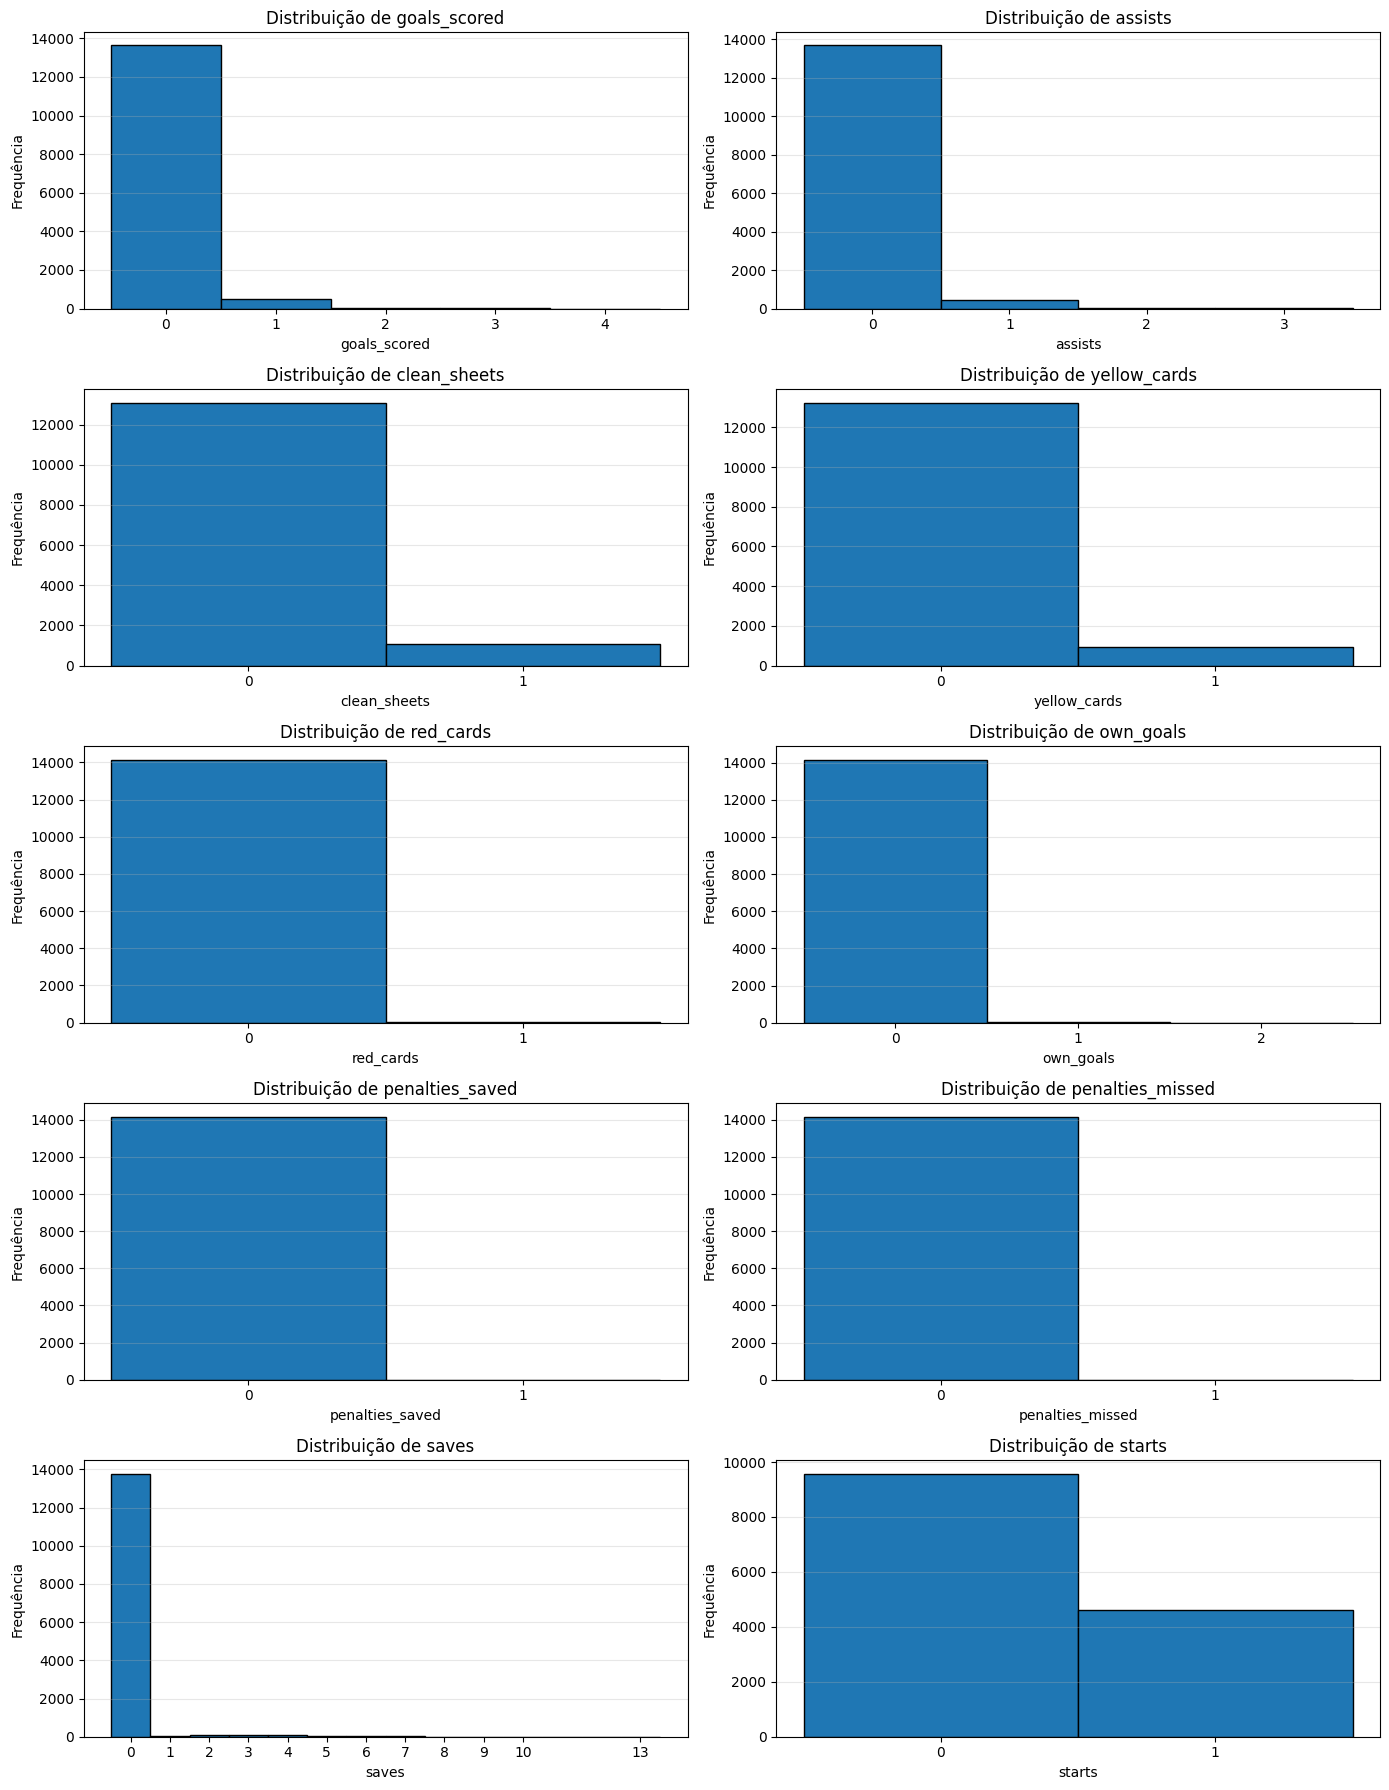

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Lista de variáveis numéricas discretas (contagens)
cols_to_plot = [
    "goals_scored", "assists", "clean_sheets", "yellow_cards",
    "red_cards", "own_goals", "penalties_saved", "penalties_missed",
    "saves", "starts"
]

# Criar subplots
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 18))
axes = axes.ravel()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    # Criar histograma
    ax.hist(df[col], bins=np.arange(df[col].min(), df[col].max() + 2) - 0.5, edgecolor='black')
    
    # Definir ticks inteiros
    unique_vals = sorted(df[col].unique())
    ax.set_xticks(unique_vals)
    
    # Títulos
    ax.set_title(f"Distribuição de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Com base na distribuição observada, as seguintes regras de transformação para finalizar a preparação dos dados serão aplicadas:

1. Conversão para Presença/Ausência: Atributos como ``goals_scored``, ``assists`` e ``own_goals`` serão binarizados. Independentemente da quantidade (ex: 1 ou 3 golos), o valor será 1 se o evento ocorreu e 0 caso contrário.

2. Variáveis Nativas Binárias: Os atributos ``clean_sheets``, ``yellow_cards``, ``red_cards``, ``penalties_saved``, ``penalties_missed`` e ``starts`` não sofrerão alterações, uma vez que os seus valores já se encontram estritamente entre 0 e 1.

3. Categorização da Variável saves: Devido à amplitude de valores (0 a 13), esta métrica será segmentada em quatro novos atributos que qualificam a performance do guarda-redes:

- save_null (0);

- save_low (1–2);

- save_medium (3–5);

- save_high (7–13).

Esta abordagem permite gerar regras como:

> *“Jogador marcou e esteve a jogar em casa → alta probabilidade de obter bonus.”*


In [8]:
import pandas as pd

df_bin = df_onehot.copy()

# Discretização binária para colunas de contagem
binary_cols = [
    "goals_scored", "assists", "own_goals",
]

for col in binary_cols:
    df_bin[col] = (df_bin[col] >= 1).astype(int)

# Discretização específica para "saves"
df_bin["save_null"] = (df_bin["saves"] == 0).astype(int)
df_bin["save_low"] = (df_bin["saves"] <= 2).astype(int)
df_bin["save_medium"] = ((df_bin["saves"] > 2) & (df_bin["saves"] <= 5)).astype(int)
df_bin["save_high"] = (df_bin["saves"] > 5).astype(int)

# (opcional: remover a coluna original)
df_bin.drop(columns=["saves"], inplace=True)

#### **2. Discretização por faixas para variáveis contínuas**

A binarização direta não é adequada para métricas de performance contínuas, tais como ``ict_index``, ``creativity``, ou ``total_points``. `

Para preservar a granularidade destes dados num formato compatível com o algoritmo Apriori, aplicou-se uma discretização em faixas.

A metodologia selecionada consiste na divisão das variáveis em tercis, classificando os valores em três níveis qualitativos: baixo, médio e alto. 

Deste modo, antes de executar a transformação dos dados, analisaram-se os histogramas de distribuição (figura abaixo) para compreender a dispersão dos valores e confirmar a viabilidade da segmentação em três intervalos distintos.

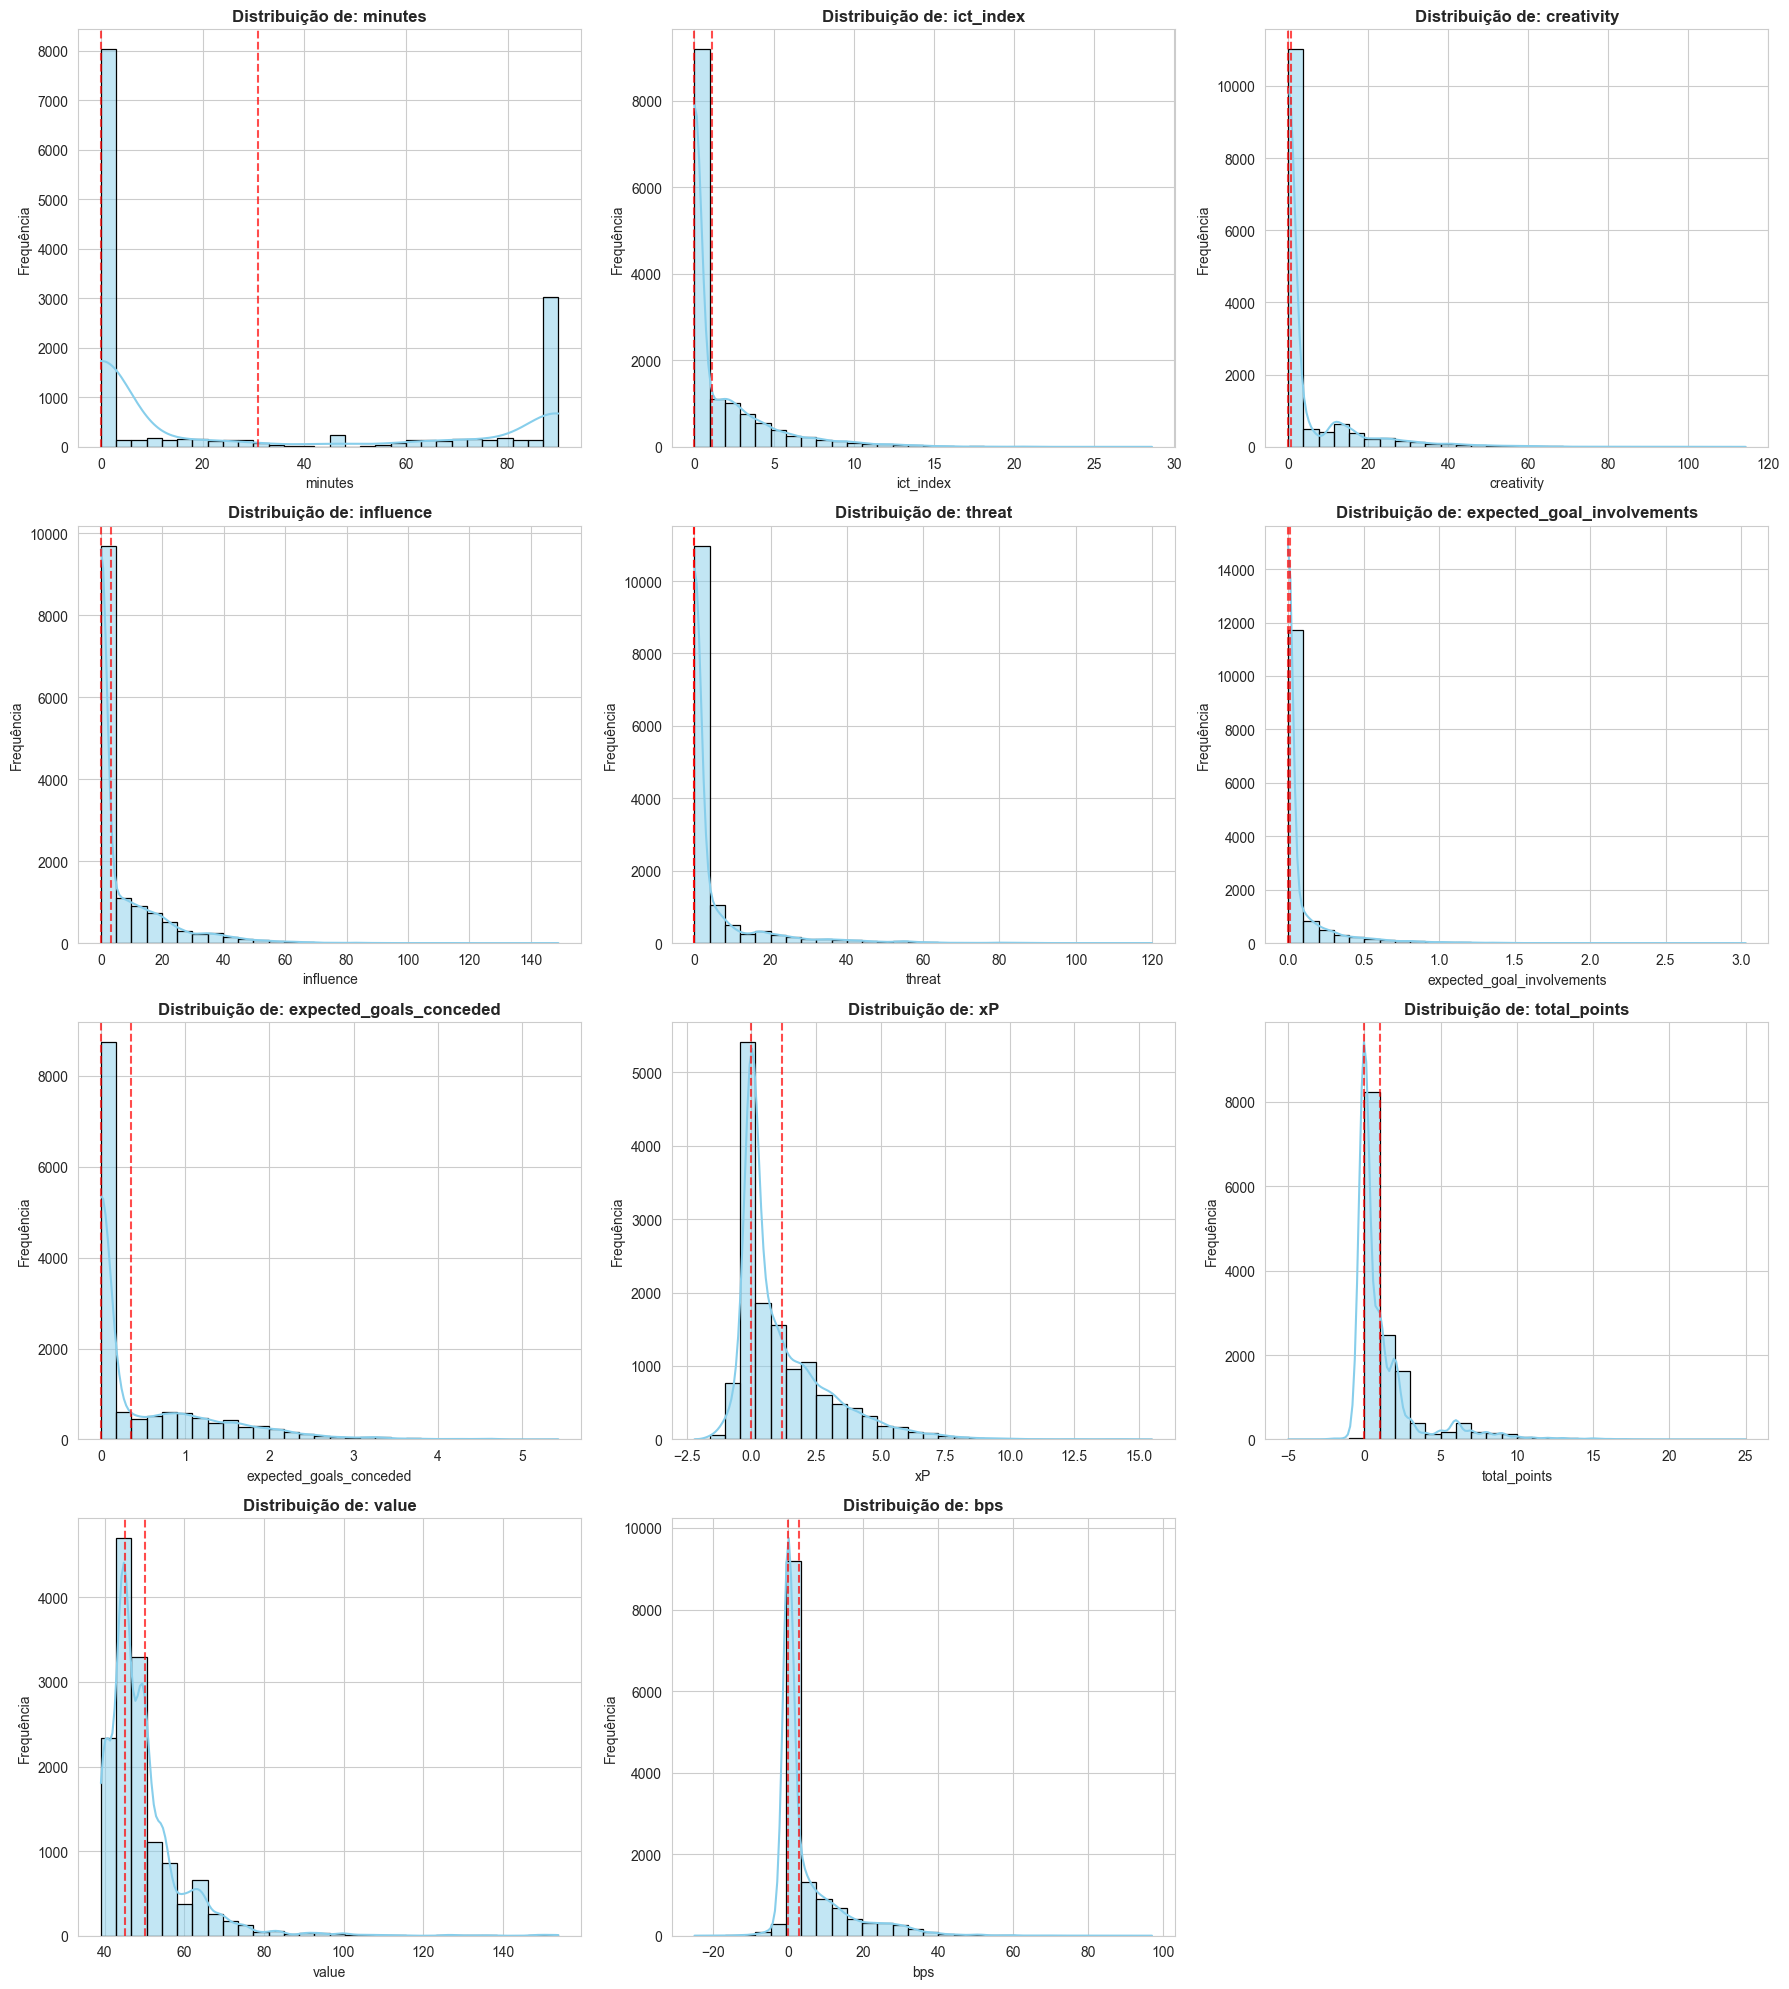

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Lista de variáveis contínuas a analisar (incluindo minutos e value)
vars_to_plot = [
    "minutes", 
    "ict_index", "creativity", "influence", "threat",
    "expected_goal_involvements", "expected_goals_conceded",
    "xP", "total_points", "value", "bps"
]

# Configuração do estilo dos gráficos
sns.set_style("whitegrid")
n_cols = 3
n_rows = math.ceil(len(vars_to_plot) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(vars_to_plot):
    if col in df.columns: # Verifica se a coluna existe no dataframe
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Histograma com curva de densidade (KDE)
        # O 'log_scale' pode ser útil se houver muitos valores pequenos e poucos gigantes
        sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
        
        plt.title(f'Distribuição de: {col}', fontsize=12, fontweight='bold')
        plt.xlabel(col)
        plt.ylabel('Frequência')
        
        # Opcional: Adicionar linhas verticais para simular onde ficariam os tercis (33% e 66%)
        try:
            quantiles = df[col].quantile([0.33, 0.66]).values
            for q in quantiles:
                plt.axvline(q, color='red', linestyle='--', alpha=0.7, label='Tercil' if q == quantiles[0] else "")
        except:
            pass
    else:
        print(f"A coluna {col} não foi encontrada no DataFrame.")

plt.tight_layout()
plt.show()

A análise visual dos histogramas e curvas de densidade (KDE) permitiu identificar padrões distintos no comportamento das variáveis, exigindo estratégias de transformação específicas para cada grupo de atributos. Abaixo, detalham-se as conclusões analíticas e o respetivo código de implementação.

##### **2.1. Tratamento da Participação (Minutos)**

A variável ``minutes`` apresenta uma distribuição bimodal extrema: um pico acentuado em 0 (jogadores que não entraram em campo) e outro em torno de 90 (jogadores que completaram a partida).

A inclusão de jogadores com 0 minutos geraria regras de associação triviais e sem valor analítico (ex: Se não jogou $\rightarrow$ Não marcou).

**Decisão**:

- **Filtragem**: Remover todos os registos onde minutes == 0.

- **Binarização**: Criar a variável played_60+, dado que jogar mais de 60 minutos é um limiar crítico nas regras de Fantasy Football (condição para Clean Sheet e pontos de presença).

In [10]:
# Remover jogadores que não entraram em campo para evitar regras triviais
print(f"Registos antes do filtro: {len(df_bin)}")
df_bin = df_bin[df_bin["minutes"] > 0].copy()
print(f"Registos após filtro (>0 min): {len(df_bin)}")

# Criar flag para quem jogou pelo menos 60 minutos (Regra de Negócio)
df_bin["played_60+"] = (df_bin["minutes"] >= 60).astype(int)

# Remover a coluna original de minutos
df_bin.drop(columns=["minutes"], inplace=True)

Registos antes do filtro: 14178
Registos após filtro (>0 min): 6347


##### **2.2. Discretização de Métricas de Performance (ICT, xG, xA)**

As variáveis de performance (como ``threat``, ``influence``, ``ict_index``, ``expected_goal_involvements``) exibem uma forte assimetria positiva (Right Skew). A maioria dos jogadores concentra-se em valores baixos, enquanto uma minoria atinge valores elevados. Uma divisão linear (intervalos iguais) seria ineficaz.

Logo, optou-se pela discretização baseada em Quantis (Tercis), dividindo a amostra em três grupos de população equivalente: Low, Medium e High. Para garantir a robustez do código contra variáveis com excesso de zeros (ex: 60% dos valores serem 0), implementou-se uma função de "Discretização Segura" (``safe_qcut``) que ajusta os intervalos dinamicamente.

In [11]:
def safe_qcut(series, k=3, labels=["Low", "Medium", "High"]):
    """
    Função auxiliar: Tenta dividir em k quantis. Se houver muitos valores repetidos
    (ex: zeros), ajusta os bins para evitar erros de execução.
    """
    try:
        return pd.qcut(series, q=k, labels=labels, duplicates='drop')
    except ValueError:
        return pd.qcut(series, q=k, duplicates='drop').astype(str)

continuous_cols = [
    "ict_index", "creativity", "influence", "threat",
    "expected_goal_involvements", "expected_goals_conceded",
    "xP", "bps"
]

labels_perf = ["Low", "Medium", "High"]

for col in continuous_cols:
    if col in df_bin.columns:
        # 1. Aplicar a discretização segura
        df_bin[col + "_tier"] = safe_qcut(df_bin[col], k=3, labels=labels_perf)
        
        # 2. Adicionar prefixo para clareza na regra (ex: 'threat_High')
        df_bin[col + "_tier"] = col + "_" + df_bin[col + "_tier"].astype(str)
        
        # 3. Remover coluna original
        df_bin.drop(columns=[col], inplace=True)

##### **2.3. Segmentação de Valor e Pontuação (Variáveis de Contexto e Alvo)**

As variáveis value (preço) e total_points (pontuação final) apresentam uma distribuição mais uniforme ou próxima da normalidade comparativamente às métricas de jogo.

**Decisão**: Aplica-se a divisão em tercis com rótulos semânticos específicos para facilitar a interpretação das regras finais:

- **Valor**: Budget (Económico), Mid (Intermédio), Premium (Caro).

- **Pontos**: Points_Low, Points_Medium, Points_High.

In [12]:
# --- Variável Target: Pontos Totais ---
if "total_points" in df_bin.columns:
    # Divisão em tercis de performance
    df_bin["points_tier"] = safe_qcut(df_bin["total_points"], k=3, labels=["Low", "Medium", "High"])
    # Prefixo para leitura (ex: Points_High)
    df_bin["points_tier"] = "Points_" + df_bin["points_tier"].astype(str)
    df_bin.drop(columns=["total_points"], inplace=True)

# --- Variável de Contexto: Valor de Mercado ---
if "value" in df_bin.columns:
    # Divisão em faixas de preço
    df_bin["value_tier"] = safe_qcut(df_bin["value"], k=3, labels=["Budget", "Mid", "Premium"])
    # Prefixo (ex: Value_Premium)
    df_bin["value_tier"] = "Value_" + df_bin["value_tier"].astype(str)
    df_bin.drop(columns=["value"], inplace=True)

# --- Variável de Contexto: Casa/Fora ---
if "was_home" in df_bin.columns:
    # Garantir formato binário numérico (0 ou 1)
    df_bin["was_home"] = df_bin["was_home"].astype(int)

# Visualização do resultado final
print("Colunas finais transformadas:")
print(df_bin.columns.tolist())
display(df_bin.head())

Colunas finais transformadas:
['assists', 'bonus', 'clean_sheets', 'goals_conceded', 'goals_scored', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'starts', 'was_home', 'yellow_cards', 'GW', 'pos_DEF', 'pos_FWD', 'pos_GK', 'pos_MID', 'team_Arsenal', 'team_Aston Villa', 'team_Bournemouth', 'team_Brentford', 'team_Brighton', 'team_Chelsea', 'team_Crystal Palace', 'team_Everton', 'team_Fulham', 'team_Ipswich', 'team_Leicester', 'team_Liverpool', 'team_Man City', 'team_Man Utd', 'team_Newcastle', "team_Nott'm Forest", 'team_Southampton', 'team_Spurs', 'team_West Ham', 'team_Wolves', 'save_null', 'save_low', 'save_medium', 'save_high', 'played_60+', 'ict_index_tier', 'creativity_tier', 'influence_tier', 'threat_tier', 'expected_goal_involvements_tier', 'expected_goals_conceded_tier', 'xP_tier', 'bps_tier', 'points_tier', 'value_tier']


,assists,bonus,clean_sheets,goals_conceded,goals_scored,own_goals,penalties_missed,penalties_saved,red_cards,starts,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,team_Arsenal,team_Aston Villa,team_Bournemouth,team_Brentford,team_Brighton,team_Chelsea,team_Crystal Palace,team_Everton,team_Fulham,team_Ipswich,team_Leicester,team_Liverpool,team_Man City,team_Man Utd,team_Newcastle,team_Nott'm Forest,team_Southampton,team_Spurs,team_West Ham,team_Wolves,save_null,save_low,save_medium,save_high,played_60+,ict_index_tier,creativity_tier,influence_tier,threat_tier,expected_goal_involvements_tier,expected_goals_conceded_tier,xP_tier,bps_tier,points_tier,value_tier
0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,ict_index_Medium,creativity_High,influence_High,"threat_(-0.001, 8.0]",expected_goal_involvements_Low,expected_goals_conceded_Medium,xP_Medium,bps_Medium,Points_Medium,Value_Mid
4,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1,ict_index_Medium,creativity_High,influence_Low,"threat_(8.0, 120.0]",expected_goal_involvements_High,expected_goals_conceded_Low,xP_Low,bps_Low,Points_Low,Value_Premium
5,0,0,0,1,0,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,ict_index_Medium,creativity_Medium,influence_High,"threat_(-0.001, 8.0]",expected_goal_involvements_Low,expected_goals_conceded_High,xP_Medium,bps_High,Points_Medium,Value_Budget
8,0,0,0,2,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,ict_index_Medium,creativity_High,influence_Low,"threat_(-0.001, 8.0]",expected_goal_involvements_Medium,expected_goals_conceded_Medium,xP_Low,bps_High,Points_Medium,Value_Premium
12,0,0,0,2,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,ict_index_Low,creativity_Medium,influence_Medium,"threat_(-0.001, 8.0]",expected_goal_involvements_Medium,expected_goals_conceded_Medium,xP_Low,bps_Medium,Points_Low,Value_Mid


---

## 7. Codificação das variáveis categóricas discretizadas (One-Hot Encoding)

Após o processo de discretização, as variáveis originalmente contínuas foram transformadas em categorias representadas por intervalos tiers.  

Exemplos típicos destas categorias incluem:

- `influence_High`
- `threat_(-0.001, 8.0]`
- `creativity_Medium`

Esses tiers indicam a faixa de valores em que a observação se encontra, permitindo que a futura geração de regras de associação seja aplicada sobre categorias bem definidas, em vez de valores numéricos contínuos.

Para tornar estas variáveis utilizáveis em modelos baseados em transações (como Apriori ou FP-Growth), é necessário codificá-las no formato **One-Hot Encoding**, criando uma coluna binária para cada categoria.

O objetivo desta etapa é:
- transformar explicitamente cada categoria em colunas binárias,
- garantir que todas as características categorizadas estejam prontas para algoritmos de regras de associação,
- manter nomes das novas colunas limpos e legíveis, mesmo quando se tratam de intervalos numéricos.

A seguir realiza-se o One-Hot Encoding para todas as variáveis `*_tier`.

In [13]:
# 1. Identificar colunas que precisam de ser codificadas
cols_to_encode = [col for col in df_bin.columns if df_bin[col].dtype == 'object' or df_bin[col].dtype.name == 'category']

print(f"Colunas a codificar: {cols_to_encode}")

# 2. Aplicar One-Hot Encoding
# prefix='', prefix_sep='' -> Como já pusemos os nomes nas categorias (ex: 'threat_High'),
# não queremos que o pandas adicione mais prefixos. O nome da coluna será o próprio valor.
df_final = pd.get_dummies(df_bin, columns=cols_to_encode, prefix='', prefix_sep='', dtype=int)

# Verificar se sobrou alguma coluna que não seja numérica (segurança)
non_numeric = df_final.select_dtypes(exclude=['int', 'int32', 'int64', 'float']).columns
if len(non_numeric) > 0:
    print(f"Atenção! Colunas não numéricas detetadas: {non_numeric}")
else:
    print("Sucesso: Todas as colunas são numéricas.")

# Visualização da Matriz Transacional Final
print(f"\nDimensões finais da Matriz: {df_final.shape}")
print("\nExemplo das primeiras 5 linhas (Transações):")
display(df_final.head())

# Listar todas as colunas geradas para garantir que os nomes estão corretos
print("\nLista de Itens (Atributos) disponíveis para o Apriori:")
print(df_final.columns.tolist())

Colunas a codificar: ['ict_index_tier', 'creativity_tier', 'influence_tier', 'threat_tier', 'expected_goal_involvements_tier', 'expected_goals_conceded_tier', 'xP_tier', 'bps_tier', 'points_tier', 'value_tier']
Sucesso: Todas as colunas são numéricas.

Dimensões finais da Matriz: (6347, 71)

Exemplo das primeiras 5 linhas (Transações):


,assists,bonus,clean_sheets,goals_conceded,goals_scored,own_goals,penalties_missed,penalties_saved,red_cards,starts,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,team_Arsenal,team_Aston Villa,team_Bournemouth,team_Brentford,team_Brighton,team_Chelsea,team_Crystal Palace,team_Everton,team_Fulham,team_Ipswich,team_Leicester,team_Liverpool,team_Man City,team_Man Utd,team_Newcastle,team_Nott'm Forest,team_Southampton,team_Spurs,team_West Ham,team_Wolves,save_null,save_low,save_medium,save_high,played_60+,ict_index_High,ict_index_Low,ict_index_Medium,creativity_High,creativity_Low,creativity_Medium,influence_High,influence_Low,influence_Medium,"threat_(-0.001, 8.0]","threat_(8.0, 120.0]",expected_goal_involvements_High,expected_goal_involvements_Low,expected_goal_involvements_Medium,expected_goals_conceded_High,expected_goals_conceded_Low,expected_goals_conceded_Medium,xP_High,xP_Low,xP_Medium,bps_High,bps_Low,bps_Medium,Points_High,Points_Low,Points_Medium,Value_Budget,Value_Mid,Value_Premium
0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0
4,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,1,1,0,0,0,1,0,0,1,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1
5,0,0,0,1,0,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0
8,0,0,0,2,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,1,1,0,0,0,1,0,1,0,0,0,1,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1
12,0,0,0,2,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,1,0,0,0,1,0,0,1,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0



Lista de Itens (Atributos) disponíveis para o Apriori:
['assists', 'bonus', 'clean_sheets', 'goals_conceded', 'goals_scored', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'starts', 'was_home', 'yellow_cards', 'GW', 'pos_DEF', 'pos_FWD', 'pos_GK', 'pos_MID', 'team_Arsenal', 'team_Aston Villa', 'team_Bournemouth', 'team_Brentford', 'team_Brighton', 'team_Chelsea', 'team_Crystal Palace', 'team_Everton', 'team_Fulham', 'team_Ipswich', 'team_Leicester', 'team_Liverpool', 'team_Man City', 'team_Man Utd', 'team_Newcastle', "team_Nott'm Forest", 'team_Southampton', 'team_Spurs', 'team_West Ham', 'team_Wolves', 'save_null', 'save_low', 'save_medium', 'save_high', 'played_60+', 'ict_index_High', 'ict_index_Low', 'ict_index_Medium', 'creativity_High', 'creativity_Low', 'creativity_Medium', 'influence_High', 'influence_Low', 'influence_Medium', 'threat_(-0.001, 8.0]', 'threat_(8.0, 120.0]', 'expected_goal_involvements_High', 'expected_goal_involvements_Low', 'expected_goal_inv

---

## 8. Exportação do Dataset Processado

Com a conclusão da fase de pré-processamento e transformação, o dataset encontra-se agora convertido numa matriz transacional binária, pronta para ser submetida aos algoritmos de mineração de dados.

Para garantir a persistência deste trabalho e permitir a sua utilização em etapas subsequentes (ou noutros notebooks dedicados exclusivamente à modelação), exporta-se o dataframe final para um ficheiro CSV.

O ficheiro resultante, ``merged_gw_processed.csv``, será armazenado na diretoria ``data/`` e servirá de input direto para o algoritmo Apriori.

In [14]:
import os

# Definição do caminho de saída
output_path = "data/merged_gw_processed.csv"

# Garantir que a pasta 'data' existe (opcional, mas boa prática)
os.makedirs("data", exist_ok=True)

# Exportação do DataFrame final
# index=False é crucial para não criar uma coluna extra de índices ao recarregar
df_final.to_csv(output_path, index=False)

print(f"Sucesso: O dataset processado foi exportado para: {output_path}")
print(f"Dimensões do ficheiro exportado: {df_final.shape}")

Sucesso: O dataset processado foi exportado para: data/merged_gw_processed.csv
Dimensões do ficheiro exportado: (6347, 71)


---

## 9. Conclusão

A presente Análise Exploratória de Dados (EDA) cumpriu o seu objetivo primordial: transformar um conjunto de dados brutos e heterogéneos do Fantasy Premier League numa matriz transacional binária, otimizada para a aplicação de algoritmos de prospeção de regras de associação (como o Apriori).

Ao longo deste notebook, foram implementadas decisões metodológicas críticas que garantem a qualidade e a relevância dos padrões a extrair posteriormente:

**1. Curadoria e Limpeza de Dados**: A remoção de atributos administrativos e redundantes permitiu focar a análise estritamente na performance desportiva. Mais importante ainda, a filtragem de jogadores com zero minutos jogados eliminou um volume significativo de ruído estatístico, evitando a geração de regras triviais (ex: "não jogou $\rightarrow$ não pontuou") que diluiriam a qualidade dos resultados.

**2. Estratégias de Transformação Adaptadas à Distribuição**: A análise detalhada dos histogramas e densidades (KDE) fundamentou a aplicação de técnicas distintas para tipos de dados diferentes:

- **Binarização Lógica**: Para eventos de contagem esparsa (golos, cartões), onde a distinção crítica é a presença/ausência do evento.
    
- **Discretização por Quantis (Tercis)**: Para métricas contínuas e assimétricas (ICT Index, BPS, Threat), onde a segmentação em Low/Medium/High permitiu capturar matizes de performance que uma simples binarização ignoraria. A introdução da função ``safe_qcut`` garantiu a robustez do processo contra a inflação de zeros.

- **Regras de Negócio**: A criação de variáveis específicas, como played_60+ e a segmentação dos saves, alinhou o tratamento dos dados com as regras reais de pontuação do jogo.

**3. Geração da Matriz Transacional**:A etapa final de One-Hot Encoding converteu com sucesso todas as variáveis categóricas e discretizadas em atributos binários. O dataframe resultante, ``df_final``, apresenta agora uma estrutura onde cada linha representa uma "transação" de jogo completa, descrita exclusivamente por meio de atributos de presença (1) ou ausência (0).

Com isto, o dataset encontra-se agora limpo, consistente e matematicamente preparado. As colunas geradas (e.g., pos_MID, threat_High, Points_Premium) constituem um vocabulário rico que permitirá ao algoritmo de regras de associação descobrir correlações não triviais entre a posição do jogador, as suas métricas subjacentes e o retorno final em pontos.